In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Carrega o dataset
pinguins = pd.read_csv('penguins.csv')

# Renomeia colunas para facilitar o uso
pinguins.rename(columns={
    "Culmen Length (mm)": "culmen_length_mm",
    "Culmen Depth (mm)": "culmen_depth_mm",
    "Species": "species",
    "Island": "island"
}, inplace=True)

In [13]:
# 1) Variáveis categóricas e numéricas
print("Q1: Tipos de Dados")
cat_cols = pinguins.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = pinguins.select_dtypes(include=['number']).columns.tolist()
print("Categóricas:", cat_cols)
print("Numéricas:  ", num_cols, "\n")

Q1: Tipos de Dados
Categóricas: ['studyName', 'species', 'Region', 'island', 'Stage', 'Individual ID', 'Clutch Completion', 'Date Egg', 'Sex', 'Comments']
Numéricas:   ['Sample Number', 'culmen_length_mm', 'culmen_depth_mm', 'Flipper Length (mm)', 'Body Mass (g)', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)'] 



In [14]:
# 2) Dados faltantes
print("Q2: NAs por coluna")
n_missing = pinguins.isna().sum()
print(n_missing[n_missing>0], "\n")

Q2: NAs por coluna
culmen_length_mm         2
culmen_depth_mm          2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               290
dtype: int64 



In [22]:
# 3) Espécies e balanceamento
print("Q3: Contagem por Espécie")
counts = pinguins['species'].value_counts()
print(counts, "\n")
ratio = counts.min() / counts.max()
print("Classes balanceadas?", "Sim" if ratio>0.8 else "Não", "\n")

Q3: Contagem por Espécie
species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64 

Classes balanceadas? Não 



Q4: Boxplot


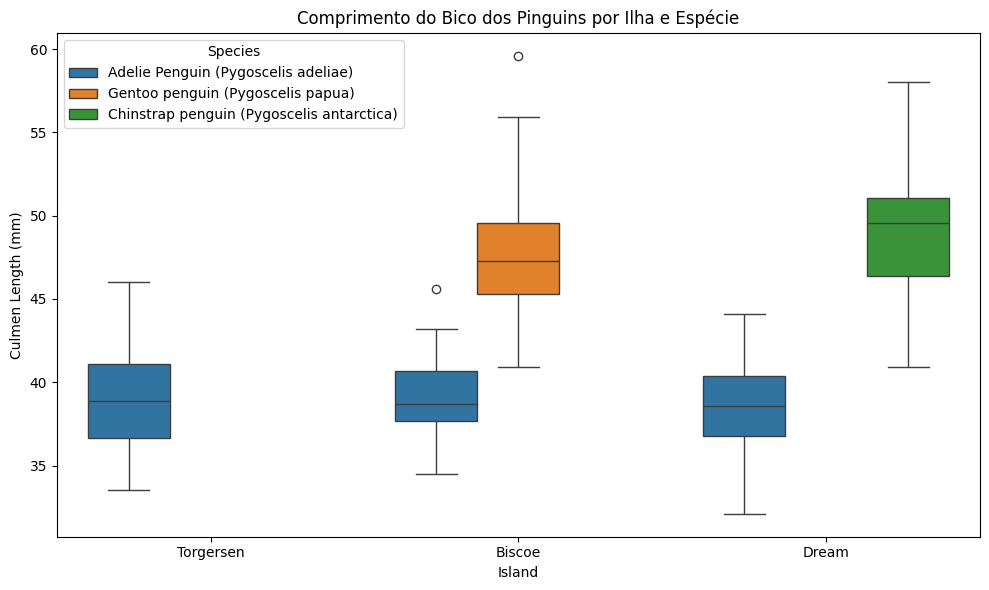

Este gráfico mostra a distribuição do comprimento do bico (culmen) das três espécies de pinguins em diferentes ilhas:
* Adelie Penguins estão presentes nas três ilhas e têm bicos curtos (mediana entre 37 e 41 mm).
* Gentoo Penguins aparecem apenas na ilha Biscoe e têm os bicos mais longos (acima de 50 mm).
* Chinstrap Penguins estão apenas na ilha Dream e têm comprimento intermediário (cerca de 48–55 mm).



In [20]:
# 4) Boxplot de Culmen Length por ilha e espécie
print("Q4: Boxplot")

# Remove linhas com valores ausentes nas colunas relevantes
pinguins_limpo = pinguins.dropna(subset=["culmen_length_mm", "species", "island"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=pinguins_limpo, x="island", y="culmen_length_mm", hue="species")
plt.xlabel("Island")
plt.ylabel("Culmen Length (mm)")
plt.title("Comprimento do Bico dos Pinguins por Ilha e Espécie")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

print("Este gráfico mostra a distribuição do comprimento do bico (culmen) das três espécies de pinguins em diferentes ilhas:")
print("* Adelie Penguins estão presentes nas três ilhas e têm bicos curtos (mediana entre 37 e 41 mm).")
print("* Gentoo Penguins aparecem apenas na ilha Biscoe e têm os bicos mais longos (acima de 50 mm).")
print("* Chinstrap Penguins estão apenas na ilha Dream e têm comprimento intermediário (cerca de 48–55 mm).\n")

Q5: Scatter Plot


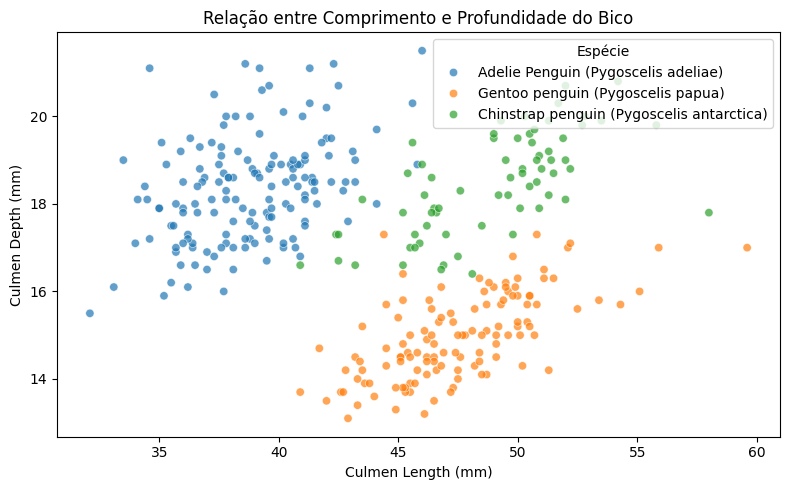

Este gráfico mostra a relação entre o comprimento (Culmen Length) e a profundidade (Culmen Depth) do bico das três espécies de pinguins:
* Adelie Penguins (azul) formam um grupo com bicos curtos (32–42 mm) e profundos (17–21 mm).
* Gentoo Penguins (laranja) têm bicos longos (42–55 mm) e rasos (13–16 mm).
* Chinstrap Penguins (verde) têm comprimento semelhante aos Gentoo (45–55 mm), mas com profundidade parecida com os Adelie (16–21 mm).

As três espécies formam grupos visivelmente separados, o que mostra que comprimento e profundidade do bico são bons atributos para diferenciá-las visualmente.


In [19]:
# 5) Scatter plot de Culmen Length x Culmen Depth
print("Q5: Scatter Plot")
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=pinguins,
    x='culmen_length_mm',
    y='culmen_depth_mm',
    hue='species',
    alpha=0.7
)
plt.title("Relação entre Comprimento e Profundidade do Bico")
plt.xlabel("Culmen Length (mm)")
plt.ylabel("Culmen Depth (mm)")
plt.legend(title="Espécie", loc="upper right")
plt.tight_layout()
plt.show()

print("Este gráfico mostra a relação entre o comprimento (Culmen Length) e a profundidade (Culmen Depth) do bico das três espécies de pinguins:")
print("* Adelie Penguins (azul) formam um grupo com bicos curtos (32–42 mm) e profundos (17–21 mm).")
print("* Gentoo Penguins (laranja) têm bicos longos (42–55 mm) e rasos (13–16 mm).")
print("* Chinstrap Penguins (verde) têm comprimento semelhante aos Gentoo (45–55 mm), mas com profundidade parecida com os Adelie (16–21 mm).")
print("\nAs três espécies formam grupos visivelmente separados, o que mostra que comprimento e profundidade do bico são bons atributos para diferenciá-las visualmente.")